# Inferencia integrada — Detección + Segmentación + Pose (YOLO26)

Pipeline que aplica **3 modelos en paralelo** a cada frame de los videos de `videos/input/`:
1. **Detección custom** (`best.pt`): factura, mate, termo
2. **Segmentación COCO** (`yolo26n-seg.pt`), excluyendo `person`, las clases custom y sus "parientes" COCO (`donut`, `cake`, `cup`) para evitar doble anotación
3. **Pose humana** (`yolo26n-pose.pt`), skeleton COCO-17

Los videos anotados se guardan en `videos/output/`.

## 0. Entorno de ejecución (VS Code + Colab, Colab web, o local)

| **Colab web con el repo en Drive** | Poner `USAR_DRIVE = True` → monta Drive y usa esa copia |
| **Local** (Jupyter en tu PC) | Busca la raíz del repo automáticamente |

> ⚠️ Requiere `best.pt` en la raíz del repo. Correr `training/train_notebook.ipynb` **en la misma sesión de Colab** justo antes de este notebook.

In [ ]:
import os
import subprocess
from pathlib import Path

# Poner en True SOLO en Colab web si querés trabajar sobre la copia del repo en
# Google Drive (flujo de Fede). Con la extensión de Colab para VS Code dejarlo
# en False: drive.mount() es inestable ahí y el repo se clona desde GitHub.
USAR_DRIVE = False

REPO_URL = 'https://github.com/samuelkanneman/TPF---Vision-por-Computadora-2026.git'
DRIVE_REPO = Path('/content/drive/MyDrive/UGR/PDI_TP2/TPF---Vision-por-Computadora-2026')

try:
    import google.colab  # noqa: F401  (¿estamos en un runtime de Colab?)
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

if not EN_COLAB:
    # Local: buscar la raíz del repo (la carpeta que contiene data/mate-termo)
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / 'data' / 'mate-termo').exists():
            os.chdir(c)
            break
    print("Entorno: local")
elif USAR_DRIVE or DRIVE_REPO.exists():
    # Colab web con el repo en Drive
    if not DRIVE_REPO.exists():
        from google.colab import drive
        drive.mount('/content/drive')
    os.chdir(DRIVE_REPO)
    print("Entorno: Colab (repo en Drive)")
else:
    # Colab sin Drive (p. ej. extensión de VS Code): clonar/sincronizar desde GitHub.
    # fetch + reset --hard sincroniza aunque el clon tenga estado local raro
    # (git pull falla con historiales divergentes) y NO borra los archivos
    # sin trackear de la VM (best.pt, runs/, videos procesados).
    repo = Path('/content/TPF---Vision-por-Computadora-2026')
    if repo.exists():
        subprocess.run(['git', '-C', str(repo), 'fetch', 'origin'], check=True)
        subprocess.run(['git', '-C', str(repo), 'reset', '--hard', 'origin/main'], check=True)
    else:
        subprocess.run(['git', 'clone', REPO_URL, str(repo)], check=True)
    os.chdir(repo)
    print("Entorno: Colab (repo clonado desde GitHub)")

print(f"Directorio de trabajo: {Path.cwd()}")

# Aviso temprano: este notebook necesita el best.pt del entrenamiento
if not Path('best.pt').exists():
    print("\n No hay best.pt en la raíz del repo: correr antes training/train_notebook.ipynb")
    print("   (idealmente en esta MISMA sesión de Colab, así best.pt ya queda acá)")

Entorno: Colab (repo clonado desde GitHub)
Directorio de trabajo: /content/TPF---Vision-por-Computadora-2026


## 1. Instalación de dependencias

In [27]:
import subprocess
import sys

# En Colab ya viene todo preinstalado y compatible: SOLO actualizar ultralytics
# (YOLO26 requiere version >= enero 2026). Actualizar Pillow/numpy/torch en Colab
# rompe dependencias ya cargadas (ej: ImportError '_Ink' de PIL).
if EN_COLAB:
    pkgs = ['ultralytics']
else:
    pkgs = ['ultralytics', 'opencv-python', 'numpy', 'torch', 'torchvision',
            'Pillow', 'matplotlib']

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-U', *pkgs], check=True)
print(f"✅ Dependencias listas: {', '.join(pkgs)}")

✅ Dependencias listas: ultralytics


## 2. Imports y configuración

Importamos las librerías y agregamos `inference/` al path para usar `utils.py`.

In [28]:
import sys
import os
import time
from pathlib import Path

# Agregar inference/ al path para importar utils
sys.path.insert(0, 'inference')

import cv2
import numpy as np
from ultralytics import YOLO

import utils

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 3. Cargar los 3 modelos

Se cargan los 3 modelos en paralelo (los archivos `.pt` se descargan automáticamente la primera vez).

> `yolo26n-seg.pt` y `yolo26n-pose.pt` existen en `ultralytics`. `best.pt` es el resultado del notebook de entrenamiento

In [ ]:
# Ajustar los nombres de los modelos segun la version disponible
SEG_MODEL_NAME    = 'yolo26n-seg.pt'    # COCO segmentation
POSE_MODEL_NAME   = 'yolo26n-pose.pt'   # pose estimation
CUSTOM_MODEL_PATH = 'best.pt'           # detector custom (entregable del training)

print("Cargando modelos...")
seg_model    = YOLO(SEG_MODEL_NAME)
pose_model   = YOLO(POSE_MODEL_NAME)
custom_model = YOLO(CUSTOM_MODEL_PATH)
print(" 3 modelos cargados:")
print(f"  - Segmentacion:  {SEG_MODEL_NAME}")
print(f"  - Pose:          {POSE_MODEL_NAME}")
print(f"  - Custom:        {CUSTOM_MODEL_PATH} ({list(custom_model.names.values())})")

Cargando modelos...
✅ 3 modelos cargados:
  - Segmentacion:  yolo26n-seg.pt
  - Pose:          yolo26n-pose.pt
  - Custom:        best.pt (['factura', 'mate', 'termo'])


## 4. Configurar videos de entrada y salida

Se procesan **todos** los videos de `videos/input/`. Cada `videoN.mp4` genera un `videos/output/resultado_videoN.mp4`.

In [30]:
from pathlib import Path

VIDEO_DIR = Path('videos/input')
OUTPUT_DIR = Path('videos/output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

videos = sorted(VIDEO_DIR.glob('*.mp4')) + sorted(VIDEO_DIR.glob('*.avi'))
if not videos:
    raise FileNotFoundError(f"❌ No hay videos en {VIDEO_DIR.resolve()} — copiarlos a videos/input/")

print(f"Se van a procesar {len(videos)} videos:")
for v in videos:
    cap = cv2.VideoCapture(str(v))
    w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    n   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    dur = n / fps if fps else 0
    print(f"  - {v.name}: {w}x{h} @ {fps:.1f} FPS, {n} frames ({dur:.1f}s)")

Se van a procesar 3 videos:
  - video1.mp4: 406x720 @ 30.0 FPS, 437 frames (14.6s)
  - video2.mp4: 480x854 @ 30.0 FPS, 812 frames (27.1s)
  - video3.mp4: 480x854 @ 30.0 FPS, 399 frames (13.3s)


## 5. Procesar todos los videos frame a frame

Para cada video: se aplican los 3 modelos a cada frame, se combinan los resultados en un único frame anotado (con overlay de FPS y conteos) y se escribe el video de salida.

> 💡 Para un test rápido, poner `MAX_FRAMES = 100` (procesa solo los primeros 100 frames de cada video).

In [ ]:
CONFIDENCE = 0.4
CUSTOM_CLASSES = list(custom_model.names.values())  # ['factura', 'mate', 'termo']
# Clases COCO "parientes" de las custom: el modelo de segmentacion ve las
# facturas como donut/cake y el mate como cup -> doble anotacion. Se excluyen.
EXTRA_EXCLUDE = ['donut', 'cake', 'cup']
MAX_FRAMES = None  # int para procesar solo N frames por video (debug), None para todo


def procesar_video(video_path, output_path):
    """Aplica los 3 modelos frame a frame y escribe el video anotado."""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"❌ No se pudo abrir {video_path}")

    w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    out = cv2.VideoWriter(str(output_path), cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

    frame_count = 0
    t_start = time.time()
    try:
        while True:
            ok, frame = cap.read()
            if not ok or (MAX_FRAMES is not None and frame_count >= MAX_FRAMES):
                break
            frame_count += 1

            # 1) Segmentacion COCO (excluye 'person', clases custom y parientes)
            seg_res = seg_model(frame, conf=CONFIDENCE, verbose=False)[0]

            # 2) Pose estimation (personas)
            pose_res = pose_model(frame, conf=CONFIDENCE, verbose=False)[0]

            # 3) Deteccion de clases custom
            cust_res = custom_model(frame, conf=CONFIDENCE, verbose=False)[0]

            # 4) Combinar todo en un unico frame
            annotated, counts = utils.annotate_frame(
                frame=frame,
                seg_result=seg_res,
                pose_result=pose_res,
                custom_result=cust_res,
                seg_model_names=seg_model.names,
                pose_model_names=pose_model.names,
                custom_model_names=custom_model.names,
                custom_class_names=CUSTOM_CLASSES + EXTRA_EXCLUDE,
                conf_threshold=CONFIDENCE,
            )

            # 5) Calcular FPS y overlay
            elapsed = time.time() - t_start
            current_fps = frame_count / elapsed if elapsed > 0 else 0
            annotated = utils.add_info_overlay(
                annotated, current_fps,
                custom_count=counts['n_custom'],
                seg_count=counts['n_seg'],
                person_count=counts['n_persons'],
            )

            out.write(annotated)

            if frame_count % 30 == 0:
                print(f"    frame {frame_count}/{total_frames} - FPS: {current_fps:.1f}")
    finally:
        cap.release()
        out.release()

    elapsed = time.time() - t_start
    print(f"  ✅ {frame_count} frames en {elapsed:.1f}s ({frame_count / max(elapsed, 1e-6):.1f} FPS promedio)")
    print(f"     Guardado en: {output_path}")


output_paths = []
for v in videos:
    out_path = OUTPUT_DIR / f"resultado_{v.stem}.mp4"
    print(f"\n🎥 Procesando {v.name} ...")
    procesar_video(v, out_path)
    output_paths.append(out_path)

print(f"\n {len(output_paths)} videos procesados en {OUTPUT_DIR}/")


🎥 Procesando video1.mp4 ...
    frame 30/437 - FPS: 14.9
    frame 60/437 - FPS: 16.3
    frame 90/437 - FPS: 16.9
    frame 120/437 - FPS: 17.3
    frame 150/437 - FPS: 17.4
    frame 180/437 - FPS: 17.6
    frame 210/437 - FPS: 16.8
    frame 240/437 - FPS: 17.0
    frame 270/437 - FPS: 17.3
    frame 300/437 - FPS: 17.5
    frame 330/437 - FPS: 17.7
    frame 360/437 - FPS: 17.8
    frame 390/437 - FPS: 17.9
    frame 420/437 - FPS: 17.7
  ✅ 437 frames en 25.0s (17.5 FPS promedio)
     Guardado en: videos/output/resultado_video1.mp4

🎥 Procesando video2.mp4 ...
    frame 30/812 - FPS: 16.4
    frame 60/812 - FPS: 17.8
    frame 90/812 - FPS: 18.5
    frame 120/812 - FPS: 18.7
    frame 150/812 - FPS: 18.8
    frame 180/812 - FPS: 18.8
    frame 210/812 - FPS: 18.3
    frame 240/812 - FPS: 17.6
    frame 270/812 - FPS: 17.6
    frame 300/812 - FPS: 17.9
    frame 330/812 - FPS: 18.0
    frame 360/812 - FPS: 18.1
    frame 390/812 - FPS: 18.1
    frame 420/812 - FPS: 18.1
    frame 4

## 6. Verificar los resultados

Muestreo de 3 frames (25% / 50% / 75%) de cada video procesado para verificar visualmente la salida.

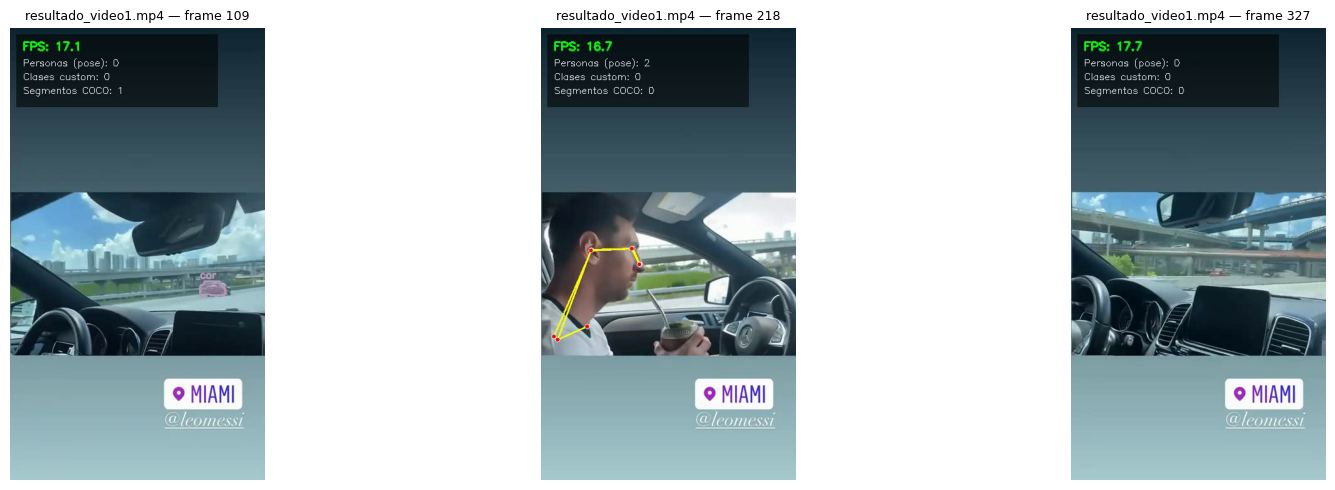

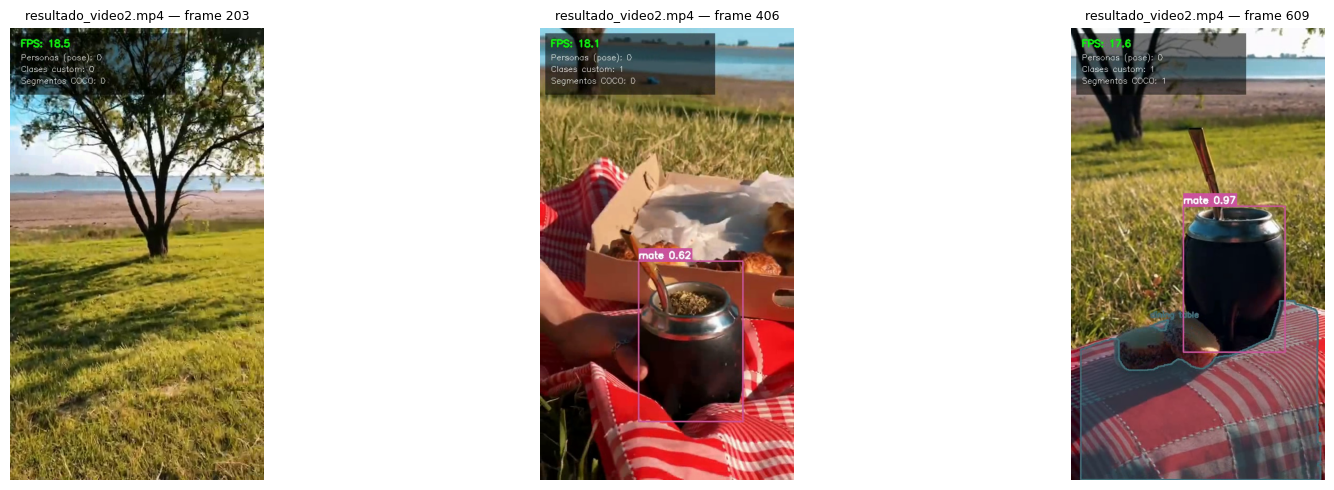

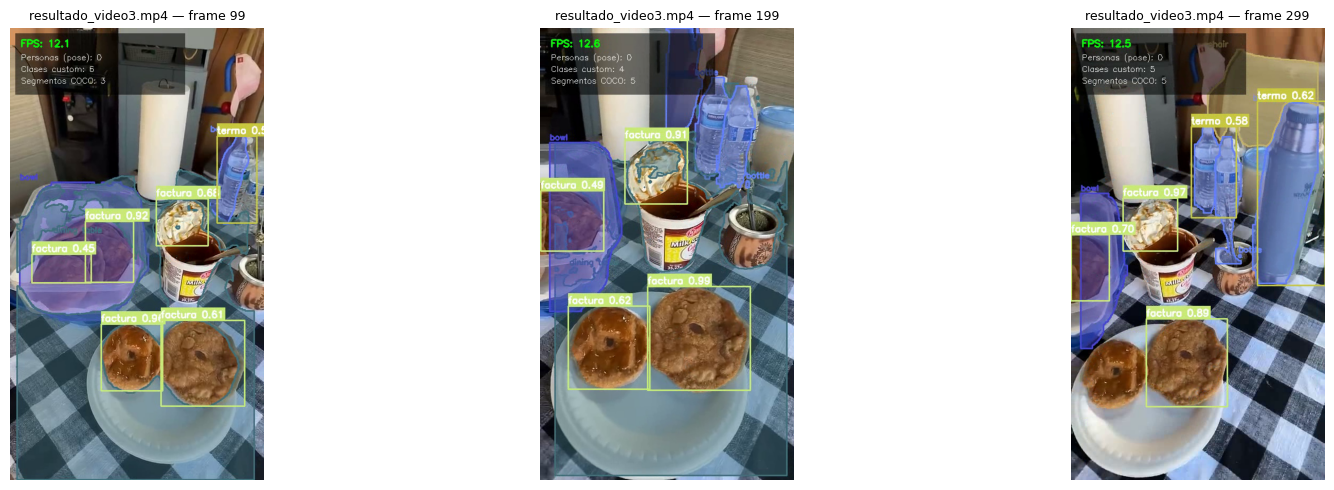

Videos completos en:
  videos/output/resultado_video1.mp4
  videos/output/resultado_video2.mp4
  videos/output/resultado_video3.mp4


In [32]:
import matplotlib.pyplot as plt

for out_path in output_paths:
    out_cap = cv2.VideoCapture(str(out_path))
    n = int(out_cap.get(cv2.CAP_PROP_FRAME_COUNT))
    # 25% / 50% / 75% del video (los extremos suelen ser frames borrosos o negros)
    samples = [n // 4, n // 2, (3 * n) // 4] if n >= 4 else list(range(n))

    fig, axes = plt.subplots(1, max(len(samples), 1), figsize=(18, 5))
    if len(samples) <= 1:
        axes = [axes]

    for ax, idx in zip(axes, samples):
        out_cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ok, f = out_cap.read()
        if ok:
            ax.imshow(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
            ax.set_title(f"{out_path.name} — frame {idx}", fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    out_cap.release()

print("Videos completos en:", *[str(p) for p in output_paths], sep='\n  ')

## 7. Descargar los videos procesados (importante en Colab)

La VM de Colab es **efímera**. Esta celda lo comprime en un zip.

In [33]:
import zipfile

ZIP_PATH = Path('videos_procesados.zip')

with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in output_paths:
        zf.write(f)

print(f"📦 {ZIP_PATH} generado ({ZIP_PATH.stat().st_size / 1e6:.1f} MB)")

if EN_COLAB:
    try:
        from google.colab import files
        files.download(str(ZIP_PATH))
    except Exception as e:
        print(f"\n⚠️ Descarga automática no disponible en este entorno ({e}).")
        print(f"   Descargá a mano: {ZIP_PATH.resolve()}")
        print("   (En VS Code: panel de archivos del runtime de Colab, o subilo a tu Drive.)")

📦 videos_procesados.zip generado (55.6 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>